In [1]:
import pandas as pd 

In [2]:
train_df = pd.read_csv(r"C:\potfolio\Customer_Churn\data\processed_data\preprocessed_data.csv")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 24 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   Unnamed: 0                             594194 non-null  int64  
 1   gender                                 594194 non-null  int64  
 2   SeniorCitizen                          594194 non-null  int64  
 3   Partner                                594194 non-null  int64  
 4   Dependents                             594194 non-null  int64  
 5   tenure                                 594194 non-null  int64  
 6   PhoneService                           594194 non-null  int64  
 7   MultipleLines                          594194 non-null  int64  
 8   OnlineSecurity                         594194 non-null  int64  
 9   OnlineBackup                           594194 non-null  int64  
 10  DeviceProtection                       594194 non-null  

In [3]:
train_df = train_df.drop(columns=["Unnamed: 0"])
bool_cols = train_df.select_dtypes("bool").columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
train_df["avg_monthly_spend"] = train_df["TotalCharges"] / (train_df["tenure"] + 1)

In [4]:
train_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,avg_monthly_spend
0,1,0,1,1,29,1,0,1,0,1,...,1,60.10,1653.85,0,0,0,1,0,0,55.128333
1,1,0,1,1,58,1,0,1,1,0,...,0,69.50,3778.20,0,1,0,0,0,0,64.037288
2,1,0,1,0,58,1,1,0,1,0,...,1,100.40,5841.35,0,0,1,0,1,0,99.005932
3,0,0,0,0,1,1,0,0,0,0,...,1,69.70,70.70,1,0,1,0,1,0,35.350000
4,0,0,0,0,1,1,0,0,0,0,...,1,70.45,70.45,1,0,1,0,1,0,35.225000


In [5]:
X = train_df.drop("Churn", axis=1)
y = train_df["Churn"]

In [6]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

In [62]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000,class_weight="balanced")

lr.fit(x_train,y_train)

c:\Users\RITHIK KUMAR\.conda\envs\torch_env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [63]:
y_pred = lr.predict(x_test)

In [64]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.79      0.86    138114
           1       0.54      0.88      0.67     40145

    accuracy                           0.81    178259
   macro avg       0.75      0.83      0.77    178259
weighted avg       0.87      0.81      0.82    178259

[[108541  29573]
 [  4734  35411]]


In [65]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(
    max_depth=6,
    random_state=42,
    n_estimators=400,
    n_jobs=-1
)

rfc.fit(x_train,y_train)

,n_estimators,400
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
rfc_pred = rfc.predict(x_test)

print(classification_report(y_test,rfc_pred))
print(confusion_matrix(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91    138114
           1       0.71      0.59      0.65     40145

    accuracy                           0.85    178259
   macro avg       0.80      0.76      0.78    178259
weighted avg       0.85      0.85      0.85    178259

[[128596   9518]
 [ 16445  23700]]


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

pipe.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [15]:
p_pred = pipe.predict(x_test)

print(classification_report(y_test,p_pred))
print(confusion_matrix(y_test,p_pred))

              precision    recall  f1-score   support

           0       0.96      0.79      0.86    138114
           1       0.54      0.88      0.67     40145

    accuracy                           0.81    178259
   macro avg       0.75      0.83      0.77    178259
weighted avg       0.87      0.81      0.82    178259

[[108472  29642]
 [  4711  35434]]


In [16]:
lr_probs = pipe.predict_proba(x_test)[:,1]

import numpy as np
threshold = 0.30
preds = (lr_probs >= threshold).astype(int)

In [34]:
coef = pipe.named_steps["model"].coef_[0]
pd.Series(coef, index=x_train.columns).sort_values()

tenure                                  -1.580682
Contract                                -0.679173
InternetService_No                      -0.438917
OnlineSecurity                          -0.172684
Dependents                              -0.150114
PhoneService                            -0.139147
TechSupport                             -0.097646
OnlineBackup                            -0.044113
MonthlyCharges                          -0.037690
DeviceProtection                        -0.029946
PaymentMethod_Mailed check              -0.027333
gender                                  -0.005058
Partner                                 -0.003762
PaymentMethod_Credit card (automatic)    0.000064
SeniorCitizen                            0.130368
StreamingMovies                          0.150113
StreamingTV                              0.164611
MultipleLines                            0.165281
PaperlessBilling                         0.203822
PaymentMethod_Electronic check           0.337254


In [35]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.98      0.69      0.81    138114
           1       0.47      0.95      0.63     40145

    accuracy                           0.75    178259
   macro avg       0.72      0.82      0.72    178259
weighted avg       0.86      0.75      0.77    178259

[[95159 42955]
 [ 2147 37998]]


In [17]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, lr_probs)

0.9093780220975287

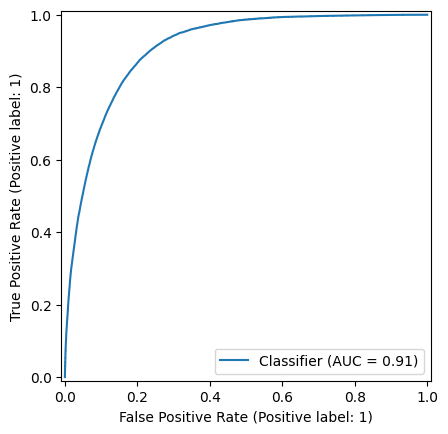

In [18]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, lr_probs)

In [ ]:
from xgboost import XGBClassifier

xgbc = XGBClassifier(
    n_estimators=500,    
    max_depth=6,            
    learning_rate=0.01,
    n_jobs = -1
)

xgbc.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
xgbc_pred = xgbc.predict(x_test)

from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test,xgbc_pred))
print(confusion_matrix(y_test,xgbc_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91    138114
           1       0.71      0.64      0.67     40145

    accuracy                           0.86    178259
   macro avg       0.80      0.78      0.79    178259
weighted avg       0.86      0.86      0.86    178259

[[127637  10477]
 [ 14386  25759]]


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(   n_estimators=1000,    
    max_depth=6,            
    learning_rate=0.01,
    n_jobs = -1))
])

pipe.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [17]:
p_pred = pipe.predict(x_test)

print(classification_report(y_test,p_pred))
print(confusion_matrix(y_test,p_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91    138114
           1       0.71      0.64      0.67     40145

    accuracy                           0.86    178259
   macro avg       0.80      0.78      0.79    178259
weighted avg       0.86      0.86      0.86    178259

[[127637  10477]
 [ 14386  25759]]


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRFClassifier
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRFClassifier(   n_estimators=500,    
    max_depth=4,            
    learning_rate=0.1,
    random_state = 42,
    n_jobs = -1))
])

rf_pipe.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,learning_rate,0.1
,subsample,0.8
,colsample_bynode,0.8
,reg_lambda,1e-05


In [23]:
p_pred = rf_pipe.predict(x_test)

print(classification_report(y_test,p_pred))
print(confusion_matrix(y_test,p_pred))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87    138114
           1       0.00      0.00      0.00     40145

    accuracy                           0.77    178259
   macro avg       0.39      0.50      0.44    178259
weighted avg       0.60      0.77      0.68    178259

[[138114      0]
 [ 40145      0]]


c:\Users\RITHIK KUMAR\.conda\envs\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RITHIK KUMAR\.conda\envs\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RITHIK KUMAR\.conda\envs\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [23]:
test_df = pd.read_csv(r"C:\potfolio\Customer_Churn\data\raw\test.csv")
test_df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [24]:
def complete_preprocessing(df):
    new_df = df.copy()
    new_df["TechSupport"] = new_df["TechSupport"].map({"Yes" : 1, "No" : 0, "No internet service": 0})

    binary_cols = ["Partner","Dependents","PhoneService","PaperlessBilling"]

    new_df[binary_cols] = new_df[binary_cols].replace({"Yes":1,"No":0})

    internet_cols = [
    "OnlineSecurity","OnlineBackup","DeviceProtection",
    "StreamingTV","StreamingMovies"
    ]

    new_df[internet_cols] = new_df[internet_cols].replace({
    "Yes":1,
    "No":0,
    "No internet service":0
    })
    contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
    }

    new_df["Contract"] = new_df["Contract"].map(contract_map)

    new_df["gender"] = new_df["gender"].map({
        "Male": 1,
        "Female": 0
    })

    new_df["MultipleLines"] = new_df["MultipleLines"].map({"Yes" : 1, "No" : 0 , "No phone service" : 0 })

    new_df = pd.get_dummies(
        new_df,
        columns=["PaymentMethod","InternetService"],
        drop_first=True
    )
    new_df.drop(columns=["id"], inplace=True)
    bool_cols = new_df.select_dtypes("bool").columns
    new_df[bool_cols] = new_df[bool_cols].astype(int)
    new_df["avg_monthly_spend"] = new_df["TotalCharges"] / (new_df["tenure"] + 1)
    return new_df

In [25]:
test_processed = complete_preprocessing(test_df)
test_processed = test_processed.reindex(columns=x_train.columns, fill_value=0)

C:\Users\RITHIK KUMAR\AppData\Local\Temp\ipykernel_19164\3073267776.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df[binary_cols] = new_df[binary_cols].replace({"Yes":1,"No":0})
C:\Users\RITHIK KUMAR\AppData\Local\Temp\ipykernel_19164\3073267776.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df[internet_cols] = new_df[internet_cols].replace({


In [71]:
test_df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [19]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(x_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 93672, number of negative: 322263
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 415935, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225208 -> initscore=-1.235569
[LightGBM] [Info] Start training from score -1.235569


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [26]:
test_probs = model.predict_proba(test_processed)[:,1]
threshold = 0.50
test_preds = (test_probs >= threshold).astype(int)
submission = pd.DataFrame({
    "id": test_df["id"],
    "Churn": test_preds
})
submission.to_csv("light_gbm_submission_1.csv", index=False)

In [20]:
lgb_probs = model.predict_proba(x_test)[:,1]

In [10]:
lg_pred = model.predict(x_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test,lg_pred))
print(confusion_matrix(y_test,lg_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91    138114
           1       0.72      0.64      0.68     40145

    accuracy                           0.86    178259
   macro avg       0.81      0.78      0.79    178259
weighted avg       0.86      0.86      0.86    178259

[[127885  10229]
 [ 14425  25720]]


In [21]:
lg_probs = model.predict_proba(x_test)[:,1]

for t in [0.30,0.35,0.40,0.45,0.50]:
    preds = (lg_probs >= t).astype(int)
    
    print(f"\nThreshold : {t}")
    print("="*60)
    print(classification_report(y_test, preds))
    print(confusion_matrix(y_test, preds))


Threshold : 0.3
              precision    recall  f1-score   support

           0       0.94      0.84      0.89    138114
           1       0.61      0.83      0.70     40145

    accuracy                           0.84    178259
   macro avg       0.77      0.83      0.80    178259
weighted avg       0.87      0.84      0.85    178259

[[116633  21481]
 [  7017  33128]]

Threshold : 0.35
              precision    recall  f1-score   support

           0       0.93      0.87      0.90    138114
           1       0.63      0.79      0.70     40145

    accuracy                           0.85    178259
   macro avg       0.78      0.83      0.80    178259
weighted avg       0.87      0.85      0.86    178259

[[119888  18226]
 [  8554  31591]]

Threshold : 0.4
              precision    recall  f1-score   support

           0       0.92      0.89      0.91    138114
           1       0.66      0.75      0.70     40145

    accuracy                           0.86    178259
   mac

In [27]:
feat_imp = pd.Series(model.feature_importances_, index=x_train.columns)
feat_imp.sort_values(ascending=False)

TotalCharges                             3283
MonthlyCharges                           2818
avg_monthly_spend                        2383
tenure                                   2104
Contract                                  466
Dependents                                317
PaymentMethod_Electronic check            311
PaperlessBilling                          302
SeniorCitizen                             299
gender                                    273
OnlineSecurity                            263
MultipleLines                             219
TechSupport                               216
OnlineBackup                              207
Partner                                   200
DeviceProtection                          196
StreamingMovies                           190
PaymentMethod_Credit card (automatic)     187
StreamingTV                               180
PaymentMethod_Mailed check                164
PhoneService                              163
InternetService_Fiber optic       

In [7]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

model.fit(x_train, y_train)

0:	learn: 0.8449614	total: 175ms	remaining: 2m 55s
100:	learn: 0.8587279	total: 2.97s	remaining: 26.5s
200:	learn: 0.8599781	total: 5.74s	remaining: 22.8s
300:	learn: 0.8608725	total: 8.59s	remaining: 19.9s
400:	learn: 0.8614952	total: 11.5s	remaining: 17.2s
500:	learn: 0.8621275	total: 14.4s	remaining: 14.4s
600:	learn: 0.8626901	total: 17.4s	remaining: 11.5s
700:	learn: 0.8632503	total: 20.4s	remaining: 8.69s
800:	learn: 0.8635917	total: 23.4s	remaining: 5.82s
900:	learn: 0.8640364	total: 26.4s	remaining: 2.9s
999:	learn: 0.8643586	total: 29.5s	remaining: 0us


In [8]:
cb_pred = model.predict(x_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test,cb_pred))
print(confusion_matrix(y_test,cb_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91    138114
           1       0.72      0.64      0.68     40145

    accuracy                           0.86    178259
   macro avg       0.81      0.78      0.79    178259
weighted avg       0.86      0.86      0.86    178259

[[127965  10149]
 [ 14467  25678]]


In [9]:
cb_probs = model.predict_proba(x_test)[:,1]
cb_preds = (cb_probs >= 0.5).astype(int)

In [10]:
print(classification_report(y_test,cb_pred))
print(confusion_matrix(y_test,cb_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91    138114
           1       0.72      0.64      0.68     40145

    accuracy                           0.86    178259
   macro avg       0.81      0.78      0.79    178259
weighted avg       0.86      0.86      0.86    178259

[[127965  10149]
 [ 14467  25678]]


In [11]:
cb_probs = model.predict_proba(x_test)[:,1]

for t in [0.30,0.35,0.40,0.45,0.50]:
    preds = (cb_probs >= t).astype(int)
    
    print(f"\nThreshold : {t}")
    print("="*60)
    print(classification_report(y_test, preds))
    print(confusion_matrix(y_test, preds))


Threshold : 0.3
              precision    recall  f1-score   support

           0       0.94      0.84      0.89    138114
           1       0.61      0.83      0.70     40145

    accuracy                           0.84    178259
   macro avg       0.77      0.84      0.79    178259
weighted avg       0.87      0.84      0.85    178259

[[116422  21692]
 [  6917  33228]]

Threshold : 0.35
              precision    recall  f1-score   support

           0       0.93      0.87      0.90    138114
           1       0.63      0.79      0.70     40145

    accuracy                           0.85    178259
   macro avg       0.78      0.83      0.80    178259
weighted avg       0.87      0.85      0.86    178259

[[119804  18310]
 [  8488  31657]]

Threshold : 0.4
              precision    recall  f1-score   support

           0       0.92      0.89      0.91    138114
           1       0.66      0.75      0.70     40145

    accuracy                           0.86    178259
   mac

In [12]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, cb_probs)

0.917142573929674

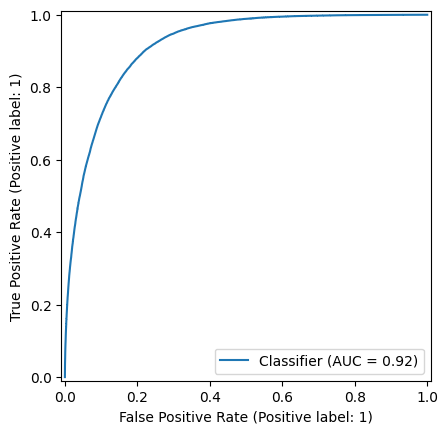

In [13]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, cb_probs)

In [21]:
ensemble_probs = (
    0.2 * lr_probs +
    0.4 * lgb_probs +
    0.4 * cb_probs
)

ensemble_preds = (ensemble_probs >= 0.45).astype(int)

In [22]:
ensemble_preds

array([0, 0, 0, ..., 1, 0, 0])

In [23]:
print(classification_report(y_test, ensemble_preds))
print(confusion_matrix(y_test, ensemble_preds))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90    138114
           1       0.65      0.76      0.70     40145

    accuracy                           0.86    178259
   macro avg       0.79      0.82      0.80    178259
weighted avg       0.86      0.86      0.86    178259

[[122077  16037]
 [  9743  30402]]


In [24]:
np.corrcoef(lgb_probs,cb_probs)

array([[1.        , 0.99730241],
       [0.99730241, 1.        ]])